In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))
from admm_colin_cantilever.admmcolinviz import ADMMColin
from matplotlib import pyplot as plt
import numpy as np
import h5py
import os

/home/harsh/anaconda3/envs/fenics_work/lib/python3.11/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
admmoc = ADMMColin(alpha=0.2, dim=64, base_dir="../admm_colin_cantilever/run_data_admm_osqp")
r = 2.3750
mesh_dim = 64
results_root=Path("OC_results_adaptive")
folder = results_root / f"{float(r):.4f}"
file_path = folder / f"{mesh_dim}.h5"

if not file_path.exists():
    print(f"Run file not found: {file_path}")

with h5py.File(file_path, "r") as h5f:
    oc_control = h5f["control_cont"][()]
    oc_control_disc = h5f["control_disc"][()]
    #oc_control_disc_T = _transpose_control_triangles(oc_control_disc, 64)
    oc_r_attr = float(h5f.attrs.get("r", r))
    oc_tv_disc = float(h5f["tv_disc"][()])
    oc_compliance_disc = float(h5f["compliance_disc"][()])

In [3]:
print(oc_tv_disc)
print(oc_compliance_disc)

477.7350647362948
17.00691691684077


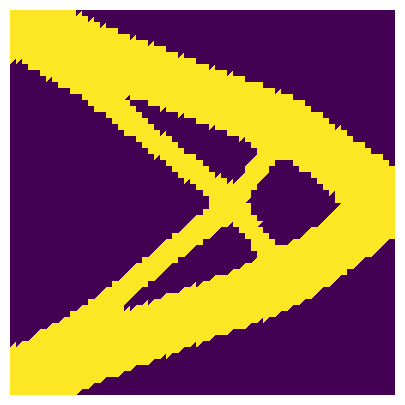

In [4]:
admmoc.plot_control(oc_control_disc)